<div style="background:#1a2745;padding:40px 44px 32px 44px;border-radius:12px;">



---



<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>

# Quando um processo pode ser simulado?

## Estacionariedade, Ruido Branco e Cartas de Controle

## Eduardo Pécora, Ph.D.

### Objetivos:

* **Objetivo 1 — Conceitual**
Compreender que todo modelo de simulação pressupõe um processo gerador de dados estacionário, e identificar as condições que esse pressuposto exige sobre média, variância e independência das observações.
* **Objetivo 2 — Prático**
Aplicar o protocolo de verificação — carta de Shewhart, função de autocorrelação (ACF) e scatter lag-1 — para diagnosticar se um conjunto de dados históricos é apto para ser usado como entrada de simulação.
---
<p style="color:#c8d8ee;margin:0;line-height:1.7;">
  <strong style="color:#f0c040;">Disciplina:</strong> Simulação de Sistemas &nbsp;·&nbsp;
  <strong style="color:#f0c040;">Pre-requisito:</strong> Estatistica basica (media, variancia, distribuição normal)
</p>
</div>

### Roteiro da aula

| # | Bloco | Pergunta central |
|---|-------|-----------------|
| 1 | **Motivação** | Por que o dado de entrada precisa ser "comportado"? |
| 2 | **Ruido branco e Bartlett** | O que significa independencia e como verificar? |
| 3 | **Autocorrelação de grau 1** | Como a dependencia entre vizinhos se manifesta? |
| 4 | **Processo estavel** | Carta de controle + ACF + Scatter |
| 5 | **Contra-exemplo 1 — Drift linear** | O que acontece quando a media cresce? |
| 6 | **Contra-exemplo 2 — Change point** | O que acontece quando o processo muda de patamar? |


## Bloco 1 — Motivação: o que a simulação exige dos dados?

Quando construimos um modelo de simulação (fila, linha de produção, sistema logistico), precisamos **alimenta-lo com distribuicoes de probabilidade** que representem o processo real — tempos de servico, inter-chegadas, duracoes de falha etc.

O procedimento padrao e:

> **Coletar dados reais -> ajustar uma distribuição -> usar essa distribuição na simulação**

### O pressuposto oculto

Esse procedimento so e valido se os dados forem amostras de **uma unica distribuição estacionaria** — isto e, se os parametros (media, variancia) forem **constantes ao longo do tempo**.

Formalmente, exigimos **estacionariedade fraca**:

$$E[x_t] = \mu \quad \forall\, t \qquad \text{e} \qquad \text{Cov}(x_t,\, x_{t+k}) = \gamma(k)$$

### O que acontece se esse pressuposto for violado?

Se a media ou a variancia variam com o tempo, os dados nao representam **uma** população — representam um mosaico de populacoes diferentes. Ajustar uma unica distribuição a esses dados produz um modelo que **nao corresponde a nenhum estado real do sistema**.

> **Simular com dados nao estacionarios é como tirar a temperatura de um paciente com febre e usar esse valor para calibrar o termostato de uma sala saudavel.**

---
## Bloco 2 — Ruído Branco e o Teorema de Bartlett

### Ruido branco

O caso mais simples de processo estacionario e o **ruido branco**: sequencia i.i.d. com media zero e variancia constante.

$$x_t \sim N(0,\, \sigma^2), \quad x_t \perp x_s \quad \forall\, t \neq s$$

Propriedades: media constante, variancia constante, **sem memoria** — saber $x_t$ nao ajuda a prever $x_{t+1}$.

### Como verificar independencia? — A ACF

$$\hat{r}_k = \frac{\displaystyle\sum_{i=1}^{n-k}(x_i - \bar{x})(x_{i+k} - \bar{x})}{\displaystyle\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

Para ruido branco verdadeiro, esperamos $r_k = 0$ para todo $k \geq 1$.

### Teorema de Bartlett (1946)

Se a série e ruido branco, cada $\hat{r}_k$ tem distribuição assintoticamente normal:

$$\hat{r}_k \xrightarrow{d}\; N\!\left(0,\;\frac{1}{n}\right)$$

**Intuição:** $\hat{r}_k$ e uma media de $n$ produtos cruzados. A variancia de uma media de $n$ termos independentes cai como $1/n$, logo o desvio padrao cai como $1/\sqrt{n}$.

### Banda de significancia (95%)

$$\text{Banda} = \pm\frac{1{,}96}{\sqrt{n}} \approx \pm\frac{2}{\sqrt{n}}$$

Se $|\hat{r}_k| > 2/\sqrt{n}$, rejeitamos $H_0$ — ha **autocorrelação significativa no lag $k$**.

> **Atenção:** a banda $\pm 2/\sqrt{n}$ e valida para o teste no **lag 1**. Para lags maiores com autocorrelação previa, a banda deveria ser corrigida (formula completa de Bartlett). Para fins de aula, usaremos a aproximação simples.


---
## Setup — bibliotecas, parâmetros e funções


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

np.random.seed(42)

# Parametros globais
N      = 200
MU     = 50.0
SIGMA  = 4.0
LAGS   = [1, 2, 3, 4, 5, 6]
UCL    = MU + 3 * SIGMA
LCL    = MU - 3 * SIGMA
CONF   = 2 / np.sqrt(N)

# Paleta
C_BLUE  = '#1a5fa8'
C_GREEN = '#1e8c5a'
C_RED   = '#c0392b'
C_AMBER = '#d4850a'
C_PURP  = '#7b3fa0'
C_GRAY  = '#7f8c8d'

# ── Funcoes auxiliares ────────────────────────────────────────────────────────
def autocorr(x, lag):
    n, m = len(x), x.mean()
    den = np.sum((x - m) ** 2)
    return np.sum((x[:n-lag] - m) * (x[lag:] - m)) / den if den else 0.0

def acf_vector(x):
    return [autocorr(x, k) for k in LAGS]

def plot_control_chart(ax, data, title, color_ok, ucl=None, cl=None, lcl=None):
    ucl = ucl if ucl is not None else UCL
    cl  = cl  if cl  is not None else MU
    lcl = lcl if lcl is not None else LCL
    obs = np.arange(1, len(data)+1)
    cols = [C_RED if (v > ucl or v < lcl) else color_ok for v in data]
    ax.plot(obs, data, color=color_ok, lw=1.1, zorder=2)
    ax.scatter(obs, data, c=cols, s=20, zorder=3)
    ax.axhline(ucl, color=C_RED,  lw=1.3, ls='--', label=f'UCL = {ucl:.1f}')
    ax.axhline(cl,  color=C_GRAY, lw=0.9, ls=':',  label=f'CL  = {cl:.1f}')
    ax.axhline(lcl, color=C_RED,  lw=1.3, ls='--', label=f'LCL = {lcl:.1f}')
    oc = int(np.sum((data > ucl) | (data < lcl)))
    ax.set_title(f'{title}  [{oc} fora]', fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('Observação', fontsize=8)
    ax.set_ylabel('Valor', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.2)
    ax.set_facecolor('white')

def plot_acf_bars(ax, acf_vals, color_ok, title):
    lag_labels = [f'Lag {k}' for k in LAGS]
    bcols = [C_RED if abs(v) > CONF else color_ok for v in acf_vals]
    bars = ax.bar(lag_labels, acf_vals, color=bcols, width=0.5, zorder=3)
    ax.axhline( CONF, color=C_GRAY, lw=1.3, ls='--', label=f'+/-2/sqrt(n) = +/-{CONF:.3f}')
    ax.axhline(-CONF, color=C_GRAY, lw=1.3, ls='--')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylim(-1, 1)
    for bar, val in zip(bars, acf_vals):
        yp = val + 0.04 if val >= 0 else val - 0.09
        ax.text(bar.get_x() + bar.get_width()/2, yp, f'{val:.3f}',
                ha='center', fontsize=8.5, fontweight='bold',
                color=C_RED if abs(val) > CONF else color_ok)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_ylabel('r_k', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, axis='y', alpha=0.2)
    ax.set_facecolor('white')
    return sum(1 for v in acf_vals if abs(v) > CONF)

def plot_scatter_lag1(ax, data, color, title):
    x_s, y_s = data[:-1], data[1:]
    sl, ic, rv, _, _ = linregress(x_s, y_s)
    r2 = rv ** 2
    ax.scatter(x_s, y_s, color=color, alpha=0.45, s=18, label='Observacoes', zorder=3)
    xs_s = np.sort(x_s)
    ax.plot(xs_s, sl*xs_s+ic, color=C_RED, lw=2, ls='--', label=f'Regressao  R2={r2:.3f}')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('x(t)', fontsize=8)
    ax.set_ylabel('x(t+1)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2, ls='--')
    ax.set_facecolor('white')
    return r2

print(f"Setup OK.  UCL={UCL:.1f}  CL={MU:.1f}  LCL={LCL:.1f}  Banda ACF=+/-{CONF:.3f}")


Setup OK.  UCL=62.0  CL=50.0  LCL=38.0  Banda ACF=+/-0.141


---
## Bloco 3 — Autocorrelação de Grau 1: a dependência entre vizinhos

Antes de ver a ACF completa, vamos entender o **lag 1** visualmente.

Se $x_t$ e $x_{t+1}$ sao independentes, o grafico de dispersao entre eles e uma **nuvem sem forma**. Se houver dependencia, veremos estrutura linear — e o $R^2$ da regressao quantifica isso.


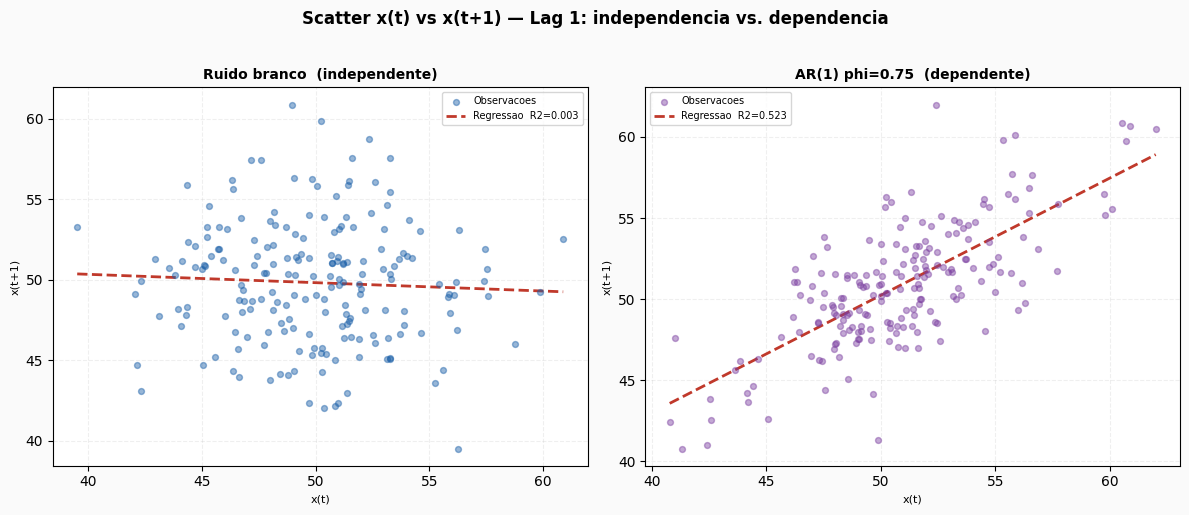

Ruido branco : R2 = 0.0027  -> nuvem dispersa -> independente
AR(1) phi=0.75 : R2 = 0.5232  -> estrutura linear -> dependente


In [8]:
# Ruido branco
wb = MU + np.random.normal(0, SIGMA, N)

# AR(1) para ilustrar dependencia (phi = 0.75)
ar1 = np.zeros(N); ar1[0] = MU; phi = 0.75
for t in range(1, N):
    ar1[t] = MU + phi*(ar1[t-1]-MU) + np.random.normal(0, SIGMA*np.sqrt(1-phi**2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#fafafa')

for ax, data, color, label in zip(
    axes,
    [wb, ar1],
    [C_BLUE, C_PURP],
    ['Ruido branco  (independente)', f'AR(1) phi={phi}  (dependente)']
):
    r2 = plot_scatter_lag1(ax, data, color, label)

fig.suptitle('Scatter x(t) vs x(t+1) — Lag 1: independencia vs. dependencia',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

r2_wb  = linregress(wb[:-1],  wb[1:])[2]**2
r2_ar1 = linregress(ar1[:-1], ar1[1:])[2]**2
print(f"Ruido branco : R2 = {r2_wb:.4f}  -> nuvem dispersa -> independente")
print(f"AR(1) phi={phi} : R2 = {r2_ar1:.4f}  -> estrutura linear -> dependente")


---
## Bloco 4 — Processo Estavel: ruido branco

Um processo com **apenas ruido branco** e o processo ideal para simulação:
- Media constante $\mu$, variancia constante $\sigma^2$
- Sem dependencia entre observacoes: ACF $\approx 0$ em todos os lags
- Scatter $x_t$ vs $x_{t+1}$ sem estrutura: $R^2 \approx 0$

Os tres graficos abaixo devem ser verificados **em conjunto** antes de aceitar um conjunto de dados para simulação.


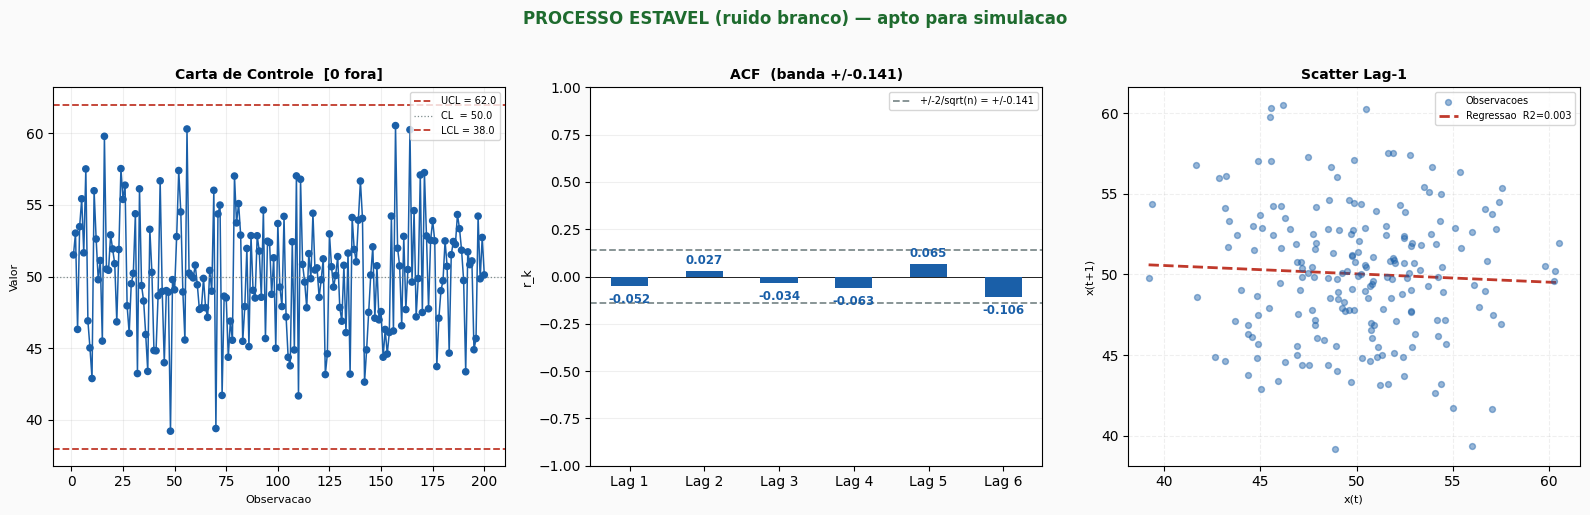

Lags significativos : 0 de 6  ->  OK: independente
R2 scatter lag-1    : 0.0027           ->  OK: sem estrutura
Media amostral      : 50.043  (alvo: 50.0)
Desvio padrao       : 4.069  (alvo: 4.0)


In [10]:
data_wb = MU + np.random.normal(0, SIGMA, N)
acf_wb  = acf_vector(data_wb)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#fafafa')

plot_control_chart(axes[0], data_wb, 'Carta de Controle', C_BLUE)
sig = plot_acf_bars(axes[1], acf_wb, C_BLUE, f'ACF  (banda +/-{CONF:.3f})')
r2 = plot_scatter_lag1(axes[2], data_wb, C_BLUE, f'Scatter Lag-1')

fig.suptitle('PROCESSO ESTAVEL (ruido branco) — apto para simulacao',
             fontsize=12, fontweight='bold', y=1.02, color='#1e6b2e')
plt.tight_layout()
plt.show()

print(f"Lags significativos : {sig} de {len(LAGS)}  ->  {'OK: independente' if sig == 0 else 'ATENCAO!'}")
print(f"R2 scatter lag-1    : {r2:.4f}           ->  {'OK: sem estrutura' if r2 < 0.05 else 'ATENCAO!'}")
print(f"Media amostral      : {data_wb.mean():.3f}  (alvo: {MU})")
print(f"Desvio padrao       : {data_wb.std():.3f}  (alvo: {SIGMA})")


---
## Bloco 5 — Contra-exemplo 1: Drift Linear

### O que e drift?

Drift e uma **tendencia sistematica** na media do processo ao longo do tempo.
Ocorre em: desgaste progressivo de ferramentas, acumulo de contaminantes, fadiga do operador.

Modelo:

$$x_t = \mu + \delta \cdot t + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma^2)$$

### Por que inviabiliza a simulacao?

A media do processo **nao e mais uma constante** — vale $\mu + \delta \cdot t$, crescendo sem parar.
Qualquer distribuição ajustada a esses dados representara uma media "de momento" que nao existira mais em seguida.

### O que esperar nos tres graficos?

- **Carta:** pontos cruzam o UCL progressivamente; muitos consecutivos acima da CL.
- **ACF:** autocorrelacoes altas e persistentes — observacoes proximas sao parecidas porque compartilham a tendencia.
- **Scatter:** nuvem inclinada com $R^2$ alto — cada observação "prevê" a proxima por herdar o mesmo drift.


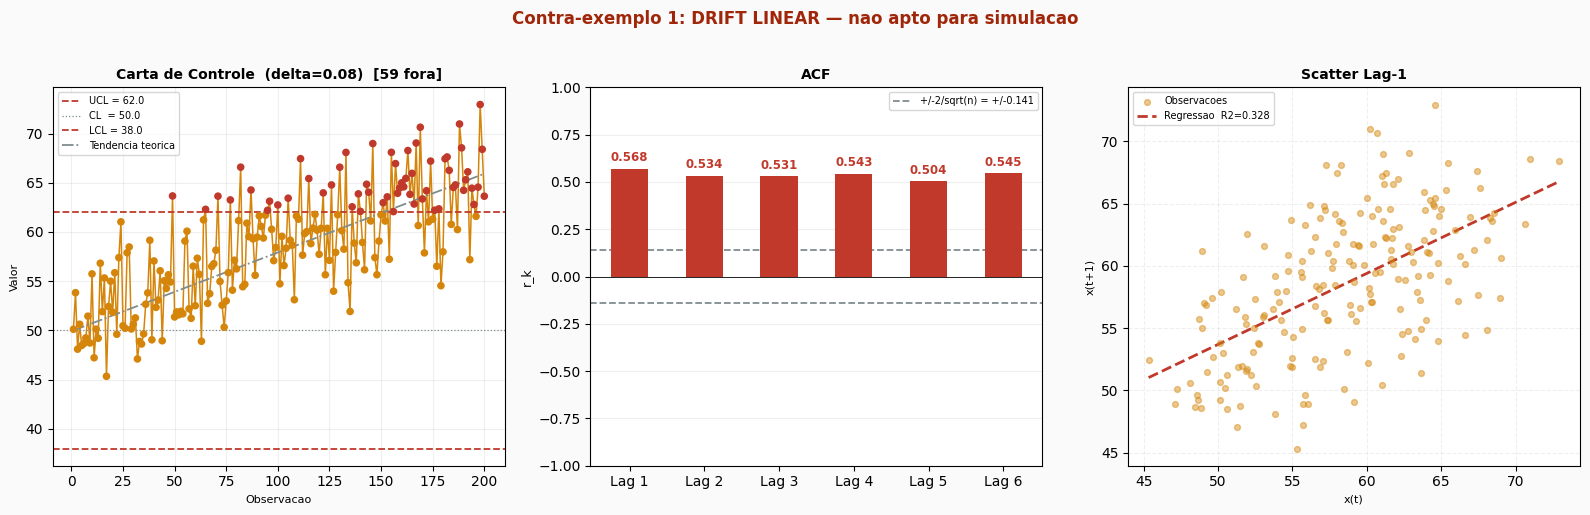

Lags significativos : 6 de 6
R2 scatter lag-1    : 0.3276  -> R2 alto = dependencia por tendencia compartilhada
Media amostral      : 58.462
Mas a media 'real' varia de 50.0 (t=0) ate 65.9 (t=199)


In [11]:
DELTA = 0.08
drift_trend = DELTA * np.arange(N)
data_drift  = MU + drift_trend + np.random.normal(0, SIGMA, N)
acf_drift   = acf_vector(data_drift)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#fafafa')

plot_control_chart(axes[0], data_drift, f'Carta de Controle  (delta={DELTA})', C_AMBER)
obs = np.arange(1, N+1)
axes[0].plot(obs, MU + drift_trend, color=C_GRAY, lw=1.3, ls='-.', label='Tendencia teorica')
axes[0].legend(fontsize=7)

sig = plot_acf_bars(axes[1], acf_drift, C_AMBER, 'ACF')
r2  = plot_scatter_lag1(axes[2], data_drift, C_AMBER, 'Scatter Lag-1')

fig.suptitle('Contra-exemplo 1: DRIFT LINEAR — nao apto para simulacao',
             fontsize=12, fontweight='bold', y=1.02, color='#a0260a')
plt.tight_layout()
plt.show()

print(f"Lags significativos : {sig} de {len(LAGS)}")
print(f"R2 scatter lag-1    : {r2:.4f}  -> R2 alto = dependencia por tendencia compartilhada")
print(f"Media amostral      : {data_drift.mean():.3f}")
print(f"Mas a media 'real' varia de {MU:.1f} (t=0) ate {MU + DELTA*(N-1):.1f} (t={N-1})")


---
## Bloco 6 — Contra-exemplo 2: Mudanca Abrupta de Nivel (Change Point)

### O que e um change point?

Diferente do drift (mudanca gradual), o **change point** e uma **mudanca abrupta e permanente** no nivel medio.
Ocorre em: troca de fornecedor, mudanca de turno, substituição de maquina, evento externo inesperado.

Modelo:

$$x_t = \begin{cases} \mu_1 + \varepsilon_t & t < t^* \\ \mu_2 + \varepsilon_t & t \geq t^* \end{cases}$$

### Por que inviabiliza a simulacao?

Os dados representam **dois processos distintos**. A media global calculada nunca foi a media real do sistema em nenhum instante — e a media de duas populacoes misturadas.

### O que esperar nos tres graficos?

- **Carta:** processo dentro dos limites, depois ruptura visivel apos $t^*$.
- **ACF:** lag 1 alto — nao por dependencia real, mas porque a media global $\bar{x}$ cai entre $\mu_1$ e $\mu_2$, fazendo todos os pontos de cada fase terem o mesmo sinal de desvio. Ver explicação detalhada abaixo.
- **Scatter:** nuvem com **dois grupos separados** visiveis, um para cada fase — isso e a assinatura visual do change point.

### Por que o lag 1 fica alto? (artefato do estimador)

O estimador $\hat{r}_1$ usa $\bar{x}$ como referencia. Com o change point, $\bar{x} \approx (\mu_1 + \mu_2)/2$:

- Fase 1: todos os pontos **abaixo** de $\bar{x}$ → desvio negativo
- Fase 2: todos os pontos **acima** de $\bar{x}$ → desvio positivo

Dentro de cada fase, dois pontos consecutivos tem o **mesmo sinal** → produto positivo → $\hat{r}_1$ alto.

Estimativa aproximada (change point no meio, $\Delta\mu = \mu_2 - \mu_1$):

$$\hat{r}_1 \approx \frac{(\Delta\mu/2)^2}{\sigma^2 + (\Delta\mu/2)^2}$$

Para $\Delta\mu = 10$ e $\sigma = 4$: $\hat{r}_1 \approx 25/41 \approx 0.61$


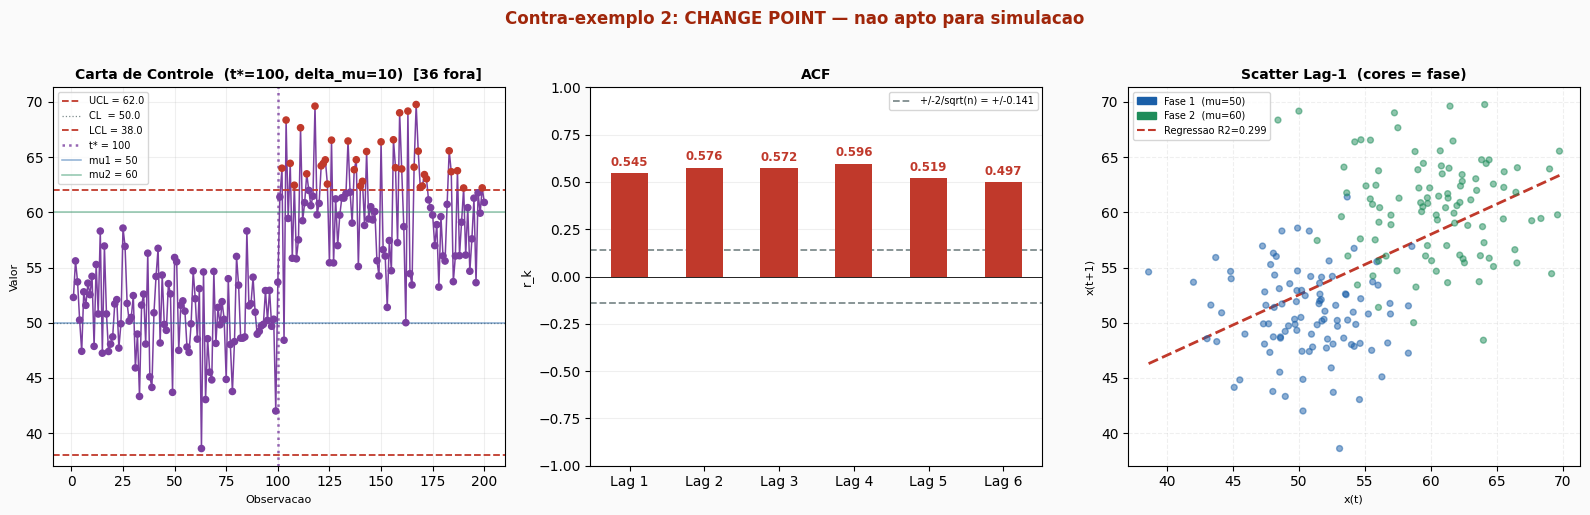

Lags significativos : 6 de 6
R2 scatter lag-1    : 0.2989  -> dois grupos visiveis no scatter
r1 observado        : 0.545
r1 teorico          : 0.610  (formula: (DeltaMu/2)^2 / (sigma^2 + (DeltaMu/2)^2))
Media global        : 55.519  (nunca foi a media real do processo)


In [12]:
T_STAR   = N // 2
DELTA_MU = 10.0

data_cp = np.concatenate([
    MU            + np.random.normal(0, SIGMA, T_STAR),
    MU + DELTA_MU + np.random.normal(0, SIGMA, N - T_STAR)
])
acf_cp = acf_vector(data_cp)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#fafafa')

plot_control_chart(axes[0], data_cp,
    f'Carta de Controle  (t*={T_STAR}, delta_mu={DELTA_MU:.0f})', C_PURP)
axes[0].axvline(T_STAR, color=C_PURP, lw=1.8, ls=':', alpha=0.8, label=f't* = {T_STAR}')
axes[0].axhline(MU,            color=C_BLUE,  lw=1.1, ls='-', alpha=0.5, label=f'mu1 = {MU:.0f}')
axes[0].axhline(MU + DELTA_MU, color=C_GREEN, lw=1.1, ls='-', alpha=0.5, label=f'mu2 = {MU+DELTA_MU:.0f}')
axes[0].legend(fontsize=7)

sig = plot_acf_bars(axes[1], acf_cp, C_PURP, 'ACF')

# Scatter com coloração por fase para revelar os dois grupos
ax = axes[2]
x_s, y_s = data_cp[:-1], data_cp[1:]
# cores por fase de origem de x_s
fase_cols = [C_BLUE if i < T_STAR else C_GREEN for i in range(len(x_s))]
ax.scatter(x_s, y_s, c=fase_cols, alpha=0.5, s=18, zorder=3)
sl, ic, rv, _, _ = linregress(x_s, y_s)
r2 = rv**2
xs_s = np.sort(x_s)
ax.plot(xs_s, sl*xs_s+ic, color=C_RED, lw=2, ls='--', label=f'Regressao  R2={r2:.3f}')
# legenda de fases
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=C_BLUE,  label=f'Fase 1  (mu={MU:.0f})'),
    Patch(color=C_GREEN, label=f'Fase 2  (mu={MU+DELTA_MU:.0f})'),
    plt.Line2D([0],[0], color=C_RED, ls='--', label=f'Regressao R2={r2:.3f}')
], fontsize=7)
ax.set_title('Scatter Lag-1  (cores = fase)', fontsize=10, fontweight='bold', pad=6)
ax.set_xlabel('x(t)', fontsize=8); ax.set_ylabel('x(t+1)', fontsize=8)
ax.grid(True, alpha=0.2, ls='--'); ax.set_facecolor('white')

fig.suptitle('Contra-exemplo 2: CHANGE POINT — nao apto para simulacao',
             fontsize=12, fontweight='bold', y=1.02, color='#a0260a')
plt.tight_layout()
plt.show()

r1_teorico = (DELTA_MU/2)**2 / (SIGMA**2 + (DELTA_MU/2)**2)
print(f"Lags significativos : {sig} de {len(LAGS)}")
print(f"R2 scatter lag-1    : {r2:.4f}  -> dois grupos visiveis no scatter")
print(f"r1 observado        : {acf_cp[0]:.3f}")
print(f"r1 teorico          : {r1_teorico:.3f}  (formula: (DeltaMu/2)^2 / (sigma^2 + (DeltaMu/2)^2))")
print(f"Media global        : {data_cp.mean():.3f}  (nunca foi a media real do processo)")


---
## Conclusao — Quadro Comparativo

| Processo | Carta de controle | ACF | Scatter lag-1 | Apto para simulacao? |
|---|---|---|---|---|
| **Ruido branco** | Pontos dentro dos limites, sem padrao | Todos os lags dentro da banda | Nuvem dispersa, $R^2 \approx 0$ | **Sim** |
| **Drift linear** | Pontos cruzam UCL progressivamente | Lags significativos e positivos | Nuvem inclinada, $R^2$ alto | **Nao** |
| **Change point** | Ruptura abrupta de nivel | Lag 1 alto (artefato de $\bar{x}$) | Dois grupos separados visiveis | **Nao** |

---

### Protocolo minimo antes de simular

```
1. Plote a série temporal — existe tendencia ou salto visivel?
2. Construa a Carta de Shewhart — ha pontos fora ou padroes sistematicos?
3. Calcule a ACF — algum |r_k| > 2/sqrt(n)?
4. Plote o scatter x(t) vs x(t+1) — ha estrutura ou grupos?

Se qualquer resposta for SIM -> investigar e corrigir antes de ajustar a distribuicao.
```

### Por que os tres graficos se complementam?

- A **carta** detecta padroes **globais** — tendencia, nivel, sazonalidade.
- A **ACF** detecta **dependencia local** — correlação entre vizinhos.
- O **scatter lag-1** revela a *natureza* do problema — drift aparece como nuvem inclinada continua; change point aparece como dois grupos separados com o mesmo $r_1$ alto, mas causa completamente diferente.

---


## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!
  

## Referências

- Bartlett, M. S. (1946). On the theoretical specification of sampling properties of autocorrelated time series. *JRSS*, 8(1), 27-41.
- Montgomery, D. C. (2020). *Introduction to Statistical Quality Control*. 8a ed. Wiley.
- Law, A. M. (2015). *Simulation Modeling and Analysis*. 5a ed. McGraw-Hill.
- Box, Jenkins & Reinsel (2015). *Time séries Analysis*. 5a ed. Wiley.


## Autor

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 12-06-2026       | 1.0     | Eduardo Pecora    | Inicial               ||

<hr>

<h3 align="center"> (c) Liga Data Science/ UFPR 2026. All rights reserved. <h3/>